# Gradient-Informed Bayesian Optimization (GIT-BO)

Contributor: rosenyu304

This notebook demonstrates **GIT-BO** [1], a high-dimensional Bayesian optimization
strategy that aligns the search with a low-dimensional *active subspace* [2] estimated
from the surrogate model's own predictive-mean input gradients:

1. A large discrete candidate set is scored with a **quantile-UCB** acquisition (the
   posterior quantile at level $\tau$; for a Gaussian posterior this equals the classic
   UCB $\mu + \sqrt{\beta}\,\sigma$ with $\beta = z_\tau^2$).
2. During the same forward pass, the Jacobian $G$ of the posterior mean w.r.t. the
   candidate inputs is obtained with a single `torch.autograd.grad` call.
3. On the next iteration, $H = G^\top G / N$ is eigendecomposed and new candidates are
   sampled inside the span of the top eigenvectors, centered at the mean of the
   evaluated points.

The implementation (`botorch_community.acquisition.gitbo`) is **surrogate-agnostic**:
any BoTorch `Model` with a posterior mean that is differentiable w.r.t. the test inputs
works. Here we benchmark GIT-BO with two surrogates — the **TabPFN v2** tabular
foundation model [3] (`TabPFNv2Model`, the surrogate used in the GIT-BO paper) and a
**`SingleTaskGP`** — against a standard `SingleTaskGP` +
`qLogNoisyExpectedImprovement` loop from the BoTorch tutorials.

[1] R. T.-Y. Yu, C. Picard, F. Ahmed.
[GIT-BO: High-Dimensional Bayesian Optimization with Tabular Foundation Models](https://arxiv.org/abs/2505.20685).
ICLR, 2026.

[2] P. G. Constantine, E. Dow, Q. Wang. Active Subspace Methods in Theory and
Practice. SIAM Journal on Scientific Computing, 2014.

[3] N. Hollmann, S. Müller, L. Purucker, et al.
[Accurate predictions on small data with a tabular foundation model](https://www.nature.com/articles/s41586-024-08328-6).
Nature, 2025.

In [1]:
import os
import time

import matplotlib.pyplot as plt
import torch
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.test_functions import Ackley
from botorch.utils.transforms import unnormalize
from botorch_community.acquisition.gitbo import gitbo_step
from gpytorch.mlls import ExactMarginalLogLikelihood

SMOKE_TEST = os.environ.get("SMOKE_TEST")
device = torch.device("cpu")

## Test problem: Ackley-30D

We maximize the (negated) 30-dimensional `Ackley` function from
`botorch.test_functions` over $[0, 1]^{30}$, mapped to Ackley's native domain — a
classic multimodal high-dimensional BO benchmark in which **all 30 dimensions are
effective**. The global optimum value is $0$, attained at $x = 0.5$ in normalized
coordinates.

In this regime GIT-BO does not rely on a sparse ground truth: the gradient-informed
subspace tracks the directions in which the surrogate's posterior mean currently
changes the most, concentrating candidates along the locally dominant descent
directions while a vanilla acquisition must search the full 30-dimensional box.
(TabPFN v2 natively supports high-dimensional tabular inputs; the GIT-BO paper [1]
benchmarks problems up to 500 dimensions.)

In [2]:
DIM = 30

ackley = Ackley(dim=DIM, negate=True)


def eval_objective(x):
    """Evaluate Ackley on the unit cube (all DIM dimensions are effective)."""
    return ackley(unnormalize(x, ackley.bounds)).unsqueeze(-1)


bounds = torch.stack([torch.zeros(DIM), torch.ones(DIM)])

## Budgets

To keep this notebook fast on CPU we use a reduced budget with the paper's default
subspace rank. The GIT-BO paper [1] uses `N_INIT=50`, 200 iterations, and 5000
candidates per iteration — increase the constants below to reproduce that setting.

In [3]:
if SMOKE_TEST:
    N_INIT = 4
    N_ITER = 2
    NUM_CANDIDATES = 128
else:
    N_INIT = 20
    N_ITER = 50
    NUM_CANDIDATES = 2048

RANK = 15  # GIT-BO paper default
SCALE = 0.2
QUANTILE = 0.975
SEED = 12345

## GIT-BO with a `SingleTaskGP` surrogate

The loop is stateless: we refit the GP on all data each iteration, call `gitbo_step`,
and carry `result.gradients` into the next call (the subspace always derives from the
previous iteration's gradients; the first iteration falls back to Sobol candidates).

In [4]:
def run_gitbo_gp(seed):
    torch.manual_seed(seed)
    tkwargs = {"device": device, "dtype": torch.double}
    train_X = torch.rand(N_INIT, DIM, **tkwargs)
    train_Y = eval_objective(train_X)
    gradients = None
    for _ in range(N_ITER):
        model = SingleTaskGP(train_X, train_Y, outcome_transform=Standardize(m=1))
        fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))
        result = gitbo_step(
            model=model,
            train_X=train_X,
            gradients=gradients,
            bounds=bounds.to(**tkwargs),
            num_candidates=NUM_CANDIDATES,
            rank=RANK,
            scale=SCALE,
            quantile=QUANTILE,
        )
        train_X = torch.cat([train_X, result.candidate])
        train_Y = torch.cat([train_Y, eval_objective(result.candidate)])
        gradients = result.gradients
    return train_Y.cpu()

## GIT-BO with the TabPFN v2 surrogate

`TabPFNv2Model` (`botorch_community.models.tabpfn_v2`) wraps the pre-trained
**TabPFN v2** regressor [3] — the tabular foundation model used as the surrogate in
the GIT-BO paper [1]. The checkpoint is downloaded from Hugging Face **once** and the
same network is re-wrapped with the current training data each iteration —
prior-fitted networks condition on the data in-context, so there is nothing to refit.
Target standardization is handled inside the model and the posterior is returned in
the raw units of `train_Y`.

> **License.** The TabPFN v2 weights are distributed under the
> [Prior Labs License](https://huggingface.co/Prior-Labs/TabPFN-v2-reg) (Apache 2.0
> with an additional attribution provision — *"Built with PriorLabs-TabPFN"*).
> Passing `accept_license=True` below (or setting the environment variable
> `BOTORCH_PFN_ACCEPT_LICENSE=1`) confirms that you accept those terms; the first
> download records your acceptance and saves a copy of the license next to the
> cached weights. Requires `pip install tabpfn`.

We pass `eval_in_q_batch=True` to `gitbo_step`: all candidates are evaluated as one
q-batch, so the PFN encodes the training context only once per forward pass — the
memory-efficient layout for PFNs (whereas GPs use the independent-marginals
`num_candidates x 1 x d` layout).

In [5]:
from botorch_community.models.tabpfn_v2 import (
    download_tabpfn_v2_regressor,
    TabPFNv2Model,
)


def run_gitbo_tabpfn(seed):
    torch.manual_seed(seed)
    tkwargs = {"device": device, "dtype": torch.float32}
    # Executing this cell with accept_license=True confirms acceptance of the
    # Prior Labs License (see the note above).
    network, bar_distribution = download_tabpfn_v2_regressor(accept_license=True)
    train_X = torch.rand(N_INIT, DIM, **tkwargs)
    train_Y = eval_objective(train_X)
    gradients = None
    for _ in range(N_ITER):
        model = TabPFNv2Model(
            train_X, train_Y, model=network, bar_distribution=bar_distribution
        )
        result = gitbo_step(
            model=model,
            train_X=train_X,
            gradients=gradients,
            bounds=bounds.to(**tkwargs),
            num_candidates=NUM_CANDIDATES,
            rank=RANK,
            scale=SCALE,
            quantile=QUANTILE,
            eval_in_q_batch=True,
        )
        train_X = torch.cat([train_X, result.candidate])
        train_Y = torch.cat([train_Y, eval_objective(result.candidate)])
        gradients = result.gradients
    return train_Y.cpu()

## Baseline: `SingleTaskGP` + `qLogNoisyExpectedImprovement`

The standard BoTorch tutorial loop: refit the GP each iteration and optimize
`qLogNEI` over the full 30-dimensional box with `optimize_acqf`.

In [6]:
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf

NUM_RESTARTS = 2 if SMOKE_TEST else 4
RAW_SAMPLES = 32 if SMOKE_TEST else 256


def run_qlognei(seed):
    torch.manual_seed(seed)
    tkwargs = {"device": device, "dtype": torch.double}
    train_X = torch.rand(N_INIT, DIM, **tkwargs)
    train_Y = eval_objective(train_X)
    for _ in range(N_ITER):
        model = SingleTaskGP(train_X, train_Y, outcome_transform=Standardize(m=1))
        fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))
        acqf = qLogNoisyExpectedImprovement(model=model, X_baseline=train_X)
        candidate, _ = optimize_acqf(
            acq_function=acqf,
            bounds=bounds.to(**tkwargs),
            q=1,
            num_restarts=NUM_RESTARTS,
            raw_samples=RAW_SAMPLES,
        )
        train_X = torch.cat([train_X, candidate])
        train_Y = torch.cat([train_Y, eval_objective(candidate)])
    return train_Y.cpu()

## Run the three methods

In [7]:
results = {}
for name, runner in [
    ("GIT-BO (TabPFN v2)", run_gitbo_tabpfn),
    ("GIT-BO (GP)", run_gitbo_gp),
    ("qLogNEI (GP)", run_qlognei),
]:
    t0 = time.monotonic()
    results[name] = runner(SEED)
    print(f"{name}: best value {results[name].max():.4f} "
          f"({time.monotonic() - t0:.1f}s)")

GIT-BO (TabPFN v2): best value -13.3603 (104.8s)


GIT-BO (GP): best value -13.2637 (70.3s)


qLogNEI (GP): best value -18.6076 (69.2s)


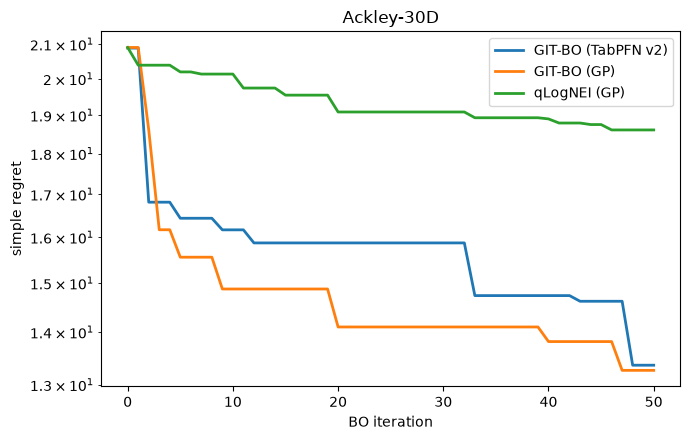

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, Y in results.items():
    best = torch.cummax(Y.squeeze(-1), dim=0).values[N_INIT - 1 :]
    # the global optimum is 0, so the simple regret is just -best
    ax.plot(range(len(best)), -best, label=name, linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("BO iteration")
ax.set_ylabel("simple regret")
ax.set_title(f"Ackley-{DIM}D")
ax.legend()
fig.tight_layout()

## Discussion

GIT-BO concentrates its candidate sets inside the estimated active subspace — the
directions in which the surrogate's posterior mean currently changes the most —
centered at the mean of the evaluated points, while the vanilla `qLogNEI` baseline
must optimize its acquisition over the full 30-dimensional box. For a rigorous
comparison, repeat the runs over multiple seeds and use the paper-scale budgets noted
above; the paper [1] benchmarks GIT-BO against state-of-the-art high-dimensional BO
methods on problems up to 500 dimensions.

*Built with PriorLabs-TabPFN.*